# OASIS pilot

Thirty-six compounds over a ten-point dose range, run in U2OS and in HepaRG, plus two batches of assay
development: `cpg0033-oasis-pilot` on the Cell Painting Gallery {cite:p}`Weisbart_2024`.

It is the dose-response dataset of the package. Every other pinned dataset either fixes one concentration per
compound or, like BBBC021, keeps only the handful of doses its mechanism benchmark needed. A four-parameter
curve has five things to estimate, so three or four concentrations leave it underdetermined and
{func}`~mantispy.tl.dose_response` can report a potency that the data does not support. Here 28 compounds carry
six or more concentrations in **each** of two cell lines, so a curve has something to hold on to and every
compound can be read twice in two different biological backgrounds.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import mantispy as mt

adata = mt.ds.oasis_pilot()
adata

/Users/tim.treis/Documents/GitHub/mantispy/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


AnnData object with n_obs × n_vars = 4604 × 99
    obs: 'Metadata_plate_map_name', 'Metadata_Plate', 'Metadata_Well', 'Metadata_Site_Count', 'Metadata_Count_Cells', 'Metadata_Count_CellsIncludingEdges', 'Metadata_Count_Cytoplasm', 'Metadata_Count_Nuclei', 'Metadata_Count_NucleiIncludingEdges', 'Metadata_Object_Count', 'Metadata_CellCount', 'Metadata_SiteCount', 'Metadata_Compound', 'Metadata_Concentration', 'Metadata_CellLine', 'Metadata_Control', 'Metadata_Perturbation'
    var: 'object', 'feature_group', 'feature', 'channel', 'scale', 'angle', 'gray_levels', 'radial_bin', 'params', 'is_feature'
    uns: 'mantispy'
    layers: None (.X)

## Source

| file | from | holds |
| --- | --- | --- |
| `<plate>_normalized_feature_select_batch.csv.gz` | `cpg0033-oasis-pilot/broad/workspace/profiles` | the well-level profiles, normalized and feature-selected per batch upstream |
| `<plate>.txt` | `cpg0033-oasis-pilot/broad/workspace/metadata/<batch>/platemap` | the plate map: which compound sits in which well, and at what concentration |

Twelve plates over four batches, read down to the 99 features they share. Columns are intersected because the
batches were feature-selected separately, which is the first thing to keep in mind: **the two cell lines were
processed apart**, so a distance computed in one is not on the same scale as a distance in the other.

In [2]:
obs = adata.obs
per_plate = obs.groupby(["Metadata_CellLine", "Metadata_Plate"], observed=True).agg(
    wells=("Metadata_Well", "size"),
    DMSO=("Metadata_Control", "sum"),
    empty=("Metadata_Compound", lambda column: int((column.astype(str) == "EMPTY").sum())),
    compounds=("Metadata_Compound", lambda column: column[~column.astype(str).isin(["DMSO", "EMPTY"])].nunique()),
    median_cells=("Metadata_CellCount", "median"),
)
per_plate

wells  DMSO  empty  compounds  median_cells
Metadata_CellLine Metadata_Plate                                             
HepaRG            BR00145690        383    32     40         36        5250.0
                  BR00145691        384    32     40         36        4842.0
                  BR00145692        384    32     40         36        4645.0
                  BR00145693        384    32     40         36        5924.0
                  BR00145694        384    32     40         36        5245.5
                  BR00145695        384    32     40         36        4250.0
                  BR00147878        384    32      0         37        5573.5
                  BR00147879        384    32      0         37        5140.5
U2OS              BR00144577        383    32     40         36         652.0
                  BR00144582        383    32     40         36         688.0

Two things stand out already. HepaRG contributes eight plates and U2OS two, so the lines are not equally
replicated, and the median cell count runs several-fold apart between them. Both are properties of the
experiment, not of the loader, and both matter when reading results across the lines.

## The plate maps do not agree with one another

The four batches were laid out at different times and none of them names its columns the same way. The loader
reads whichever pair each plate map carries:

| batch | compound column | concentration column |
| --- | --- | --- |
| `2024_03_29_OASIS_U2OS_AssayDev` | `treatment` | `concentration_uM` |
| `20241115_OASIS_U2OS_AD2`, `20241115_OASIS_HepaRG_AD` | `Compound Name` | `assay_conc_uM` |
| `2025_07_29_OASIS_HepaRG_Ptx_AD2` | `compound` | `compound_concentration` |

Two further quirks would each cost wells if ignored. In the two `Compound Name` batches that column is **blank**
for every well holding no compound, and the identifier column `BROAD_ID` carries `DMSO` or `EMPTY` instead. One
batch writes the line as `HepRG` and the others as `HepaRG`, which would split every per-line grouping in two.

The first quirk is worth seeing rather than taking on trust, because reading the obvious column alone loses the
controls — and a screen without controls silently loses every normalization and every hit call that depends on
them:

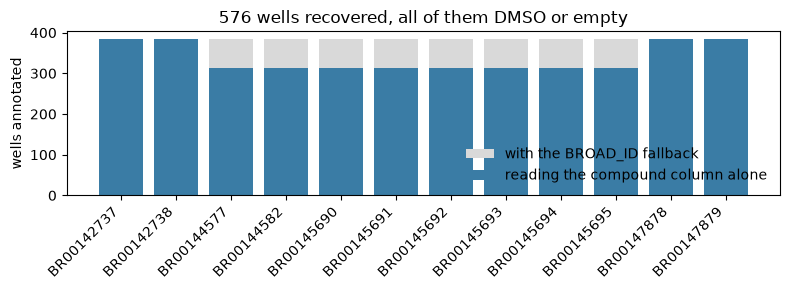

In [3]:
from mantispy.ds._datasets import _files

naive, recovered = [], []
for path in _files("oasis_pilot", None, select=lambda name: name.endswith("__platemap.txt")):
    frame = pd.read_csv(path, sep="\t", dtype=str)
    plate = path.name.split("__")[1]
    column = next(c for c in ("treatment", "Compound Name", "compound") if c in frame)
    named = frame[column].notna()
    naive.append({"plate": plate, "wells": int(named.sum())})
    filled = frame[column].fillna(frame["BROAD_ID"]) if "BROAD_ID" in frame else frame[column]
    recovered.append({"plate": plate, "wells": int(filled.notna().sum())})

naive, recovered = pd.DataFrame(naive).set_index("plate"), pd.DataFrame(recovered).set_index("plate")
fig, ax = plt.subplots(figsize=(8, 3))
x = np.arange(len(naive))
ax.bar(x, recovered["wells"], color="0.85", label="with the BROAD_ID fallback")
ax.bar(x, naive["wells"], color="#3a7ca5", label="reading the compound column alone")
ax.set_xticks(x, naive.index, rotation=45, ha="right")
ax.set(
    ylabel="wells annotated",
    title=f"{int((recovered['wells'] - naive['wells']).sum())} wells recovered, all of them DMSO or empty",
)
ax.legend(frameon=False, loc="lower right")
fig.tight_layout()

Eight plates lose 72 wells each that way, 576 in all. Every one of them is a control or a deliberately empty
well, which is exactly the set you cannot afford to drop.

## The design, as the plate sees it

The dosed plates are laid out as a dilution series across the plate, with vehicle and empty wells interleaved.
Drawing the concentration on the well grid shows the design and where the controls sit:

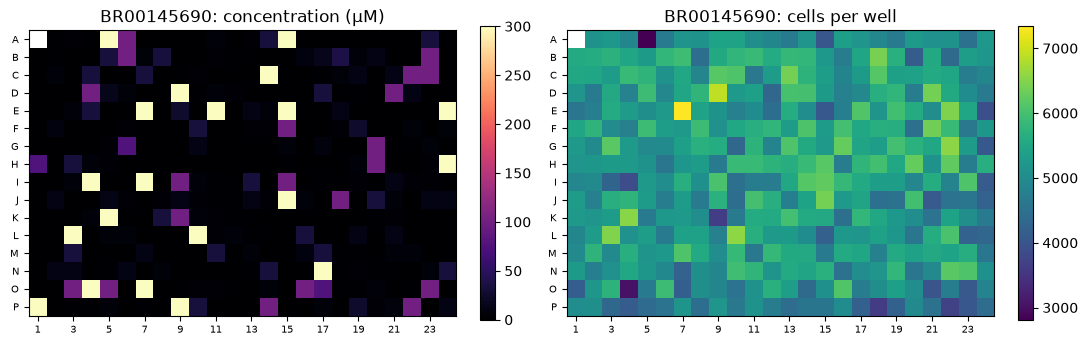

In [4]:
dosed_plate = "BR00145690"
fig, axes = plt.subplots(1, 2, figsize=(11, 3.4))
mt.pl.plate(adata, color="Metadata_Concentration", plate=dosed_plate, ax=axes[0], cmap="magma")
axes[0].set_title(f"{dosed_plate}: concentration (µM)")
mt.pl.plate(adata, color="Metadata_CellCount", plate=dosed_plate, ax=axes[1], cmap="viridis")
axes[1].set_title(f"{dosed_plate}: cells per well")
fig.tight_layout()

The blank cells on the left are the wells with no concentration to show: DMSO and the empties. On the right the
same plate in cell counts, which is where a dose series first becomes visible — the columns that carry the
highest concentrations of the more toxic compounds are the sparsest.

## Dose coverage

Concentrations are micromolar and span nearly six orders of magnitude. What matters for a curve fit is not the
range but how many distinct concentrations each compound actually carries:

56 compound-and-line pairs carry six or more concentrations


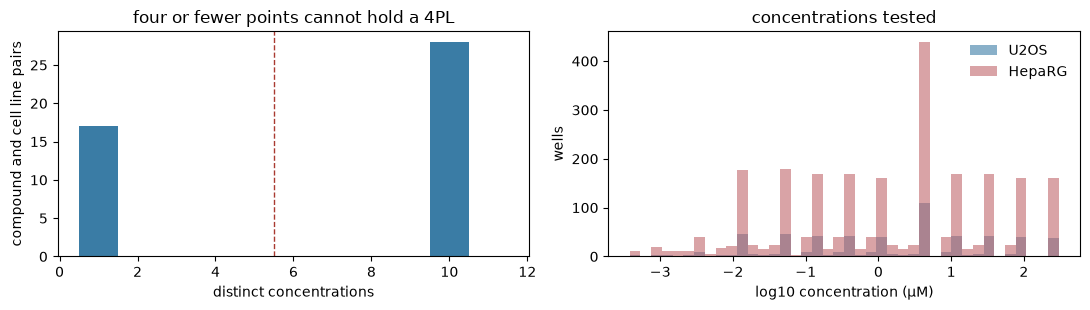

In [5]:
treated = obs[~obs["Metadata_Control"] & (obs["Metadata_Compound"].astype(str) != "EMPTY")]
doses = treated.groupby(["Metadata_CellLine", "Metadata_Compound"], observed=True)["Metadata_Concentration"].nunique()

fig, axes = plt.subplots(1, 2, figsize=(11, 3.2))
axes[0].hist(doses.to_numpy(), bins=np.arange(0.5, 12.5), color="#3a7ca5")
axes[0].axvline(5.5, color="#a93a31", ls="--", lw=1)
axes[0].set(
    xlabel="distinct concentrations",
    ylabel="compound and cell line pairs",
    title="four or fewer points cannot hold a 4PL",
)
for line, colour in (("U2OS", "#3a7ca5"), ("HepaRG", "#c1666b")):
    values = treated.loc[treated["Metadata_CellLine"] == line, "Metadata_Concentration"]
    axes[1].hist(np.log10(values[values > 0]), bins=40, alpha=0.6, color=colour, label=line)
axes[1].set(xlabel="log10 concentration (µM)", ylabel="wells", title="concentrations tested")
axes[1].legend(frameon=False)
fig.tight_layout()
print(f"{int((doses >= 6).sum())} compound-and-line pairs carry six or more concentrations")

## What a dose series looks like in the cells

A dose series shows up first in the cell count. Staurosporine is a pan-kinase inhibitor and kills cells at
concentrations where most compounds do nothing; mupirocin inhibits a bacterial enzyme and has no target in a
human cell at all. They bracket what this plate map can show.

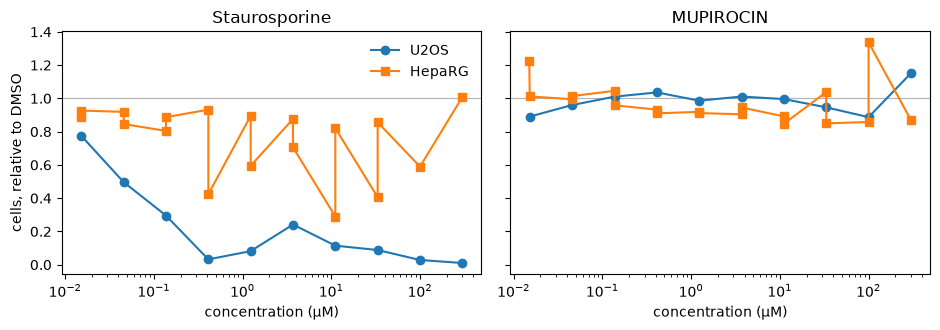

In [6]:
def per_dose(compound, line, column):
    block = treated[(treated["Metadata_Compound"].astype(str) == compound) & (treated["Metadata_CellLine"] == line)]
    return block.groupby("Metadata_Concentration", observed=True)[column].median()


fig, axes = plt.subplots(1, 2, figsize=(9.5, 3.4), sharey=True)
for ax, compound in zip(axes, ["Staurosporine", "MUPIROCIN"], strict=False):
    for line, marker in (("U2OS", "o"), ("HepaRG", "s")):
        counts = per_dose(compound, line, "Metadata_CellCount")
        vehicle = obs[(obs["Metadata_CellLine"] == line) & obs["Metadata_Control"]]["Metadata_CellCount"].median()
        ax.plot(counts.index, counts.to_numpy() / vehicle, marker=marker, label=line)
    ax.set(xscale="log", xlabel="concentration (µM)", title=compound)
    ax.axhline(1.0, color="0.7", lw=0.8, zorder=0)
axes[0].set_ylabel("cells, relative to DMSO")
axes[0].legend(frameon=False)
fig.tight_layout()

## What it is for

The count is only the crudest readout. A compound can reshape cells long before it kills any, and a
concentration-response fit on the profile finds that earlier than a fit on the count does.
[11. Concentration response](../tutorials/11_dose_response.ipynb) runs that analysis on this screen: the
continuous hit call, what it does with compounds that never plateau, how to read it beside a cell count, and
whether a call made in HepaRG survives in U2OS.

One property of the design belongs here rather than there. This plate map spends its wells on concentrations
rather than replicates, so a compound at one concentration usually sits in one or two wells. A per-concentration
test is therefore thin, and the evidence lives in the shape across the whole series. That is what the dataset is
for, and what it is not for.

## Caveats

- The profiles arrive normalized and feature-selected per batch, so the two cell lines were processed apart.
  Compare distances within a line; across lines, compare calls.
- HepaRG has eight plates and U2OS two. The HepaRG calls rest on more wells.
- The assay development batch doses DMSO itself, so a control well there carries a concentration.
  `Metadata_Control` marks the compound, not the dose.
- `EMPTY` wells hold no compound and no vehicle. They keep their label rather than being dropped, and should be
  excluded before scoring, as above.
- Concentrations are micromolar throughout, including the assay development batch, which reports its own
  `concentration_uM`.